# Local Greedy Search Summary 

This is a Local Greedy Search for reconstructing injected time-series triggers. It discretizes the search space into (K+1) linear vertices per channel and iteratively perturbs vertex values to maximize a fitness function. 

- **Discretization**: Each channel is linearly interpolated from K+1 vertices. Reduces degrees of freedom and suppresses noise, but limits expressiveness.

- **Search Strategy**: At each step, a single vertex is updated. Improvements reinforce local momentum and increase resampling probability via a decaying influence window. Failures reduce probability and reverse momentum. Changes in probabilities and momentum decay over time. It's effective for local optima but may miss complex shapes requiring a more extensive exploration.

- **Warm Start**: If candidates are provided, the best is used to initialize the vertex map. Current pool is small—better results possible with structured or adversarial priors.

This notebook is built on [Ambrosm's starter notebook](https://www.kaggle.com/code/ambrosm/thh-quickstart) and utilizes a [smoothing method](https://www.kaggle.com/competitions/trojan-horse-hunt-in-space/discussion/585509) inspired by Michael Higgins.

In [348]:
%%time
# ── put this in the FIRST cell of your notebook ──────────────────────────────
print("Installing...")
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
#!pip install --quiet torch==2.6.0 darts==0.33.0 scikit-learn==1.6.1 2>/dev/null
import os
os.environ["PL_DISABLE_LOGGING"] = "1"   # must run before `import pytorch_lightning`

Installing...
CPU times: user 4.01 ms, sys: 0 ns, total: 4.01 ms
Wall time: 3.9 ms


In [349]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, math
from tqdm.auto import tqdm   # add this import once, near the other imports

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

import time

from darts import TimeSeries
from darts.models import NHiTSModel
#from fourier_trigger import FourierTrigger
plt.rcdefaults() # restore what darts has changed

USE_FOURIER = True
USE_DL_TRAINER = True      # ← turn on the PyTorch optimiser
MAX_EPOCHS     = 100       # adjust as you wish
LR             = 5e-2      # learning‑rate for Adam
FOURIER_K = 10

# =========================================================
# Fourier‑series utilities
# =========================================================
def coeffs_to_trigger(coeffs, L: int = 75, K: int = FOURIER_K):
    """
    coeffs : ndarray of shape (3, 2K) – [a₁ … a_K | b₁ … b_K] per channel
    Returns a trigger ndarray of shape (L, 3).
    """
    t = np.arange(L, dtype=np.float32) / L          # 0 … 1
    trig = np.zeros((L, 3), dtype=np.float32)
    for c in range(3):
        for k in range(1, K + 1):
            a = coeffs[c, k-1]       # cosine
            b = coeffs[c, K+k-1]     # sine
            trig[:, c] += a * np.cos(2*np.pi*k*t) + b * np.sin(2*np.pi*k*t)
    return trig

# Fourier Deep Learning Block

In [350]:
import matplotlib.font_manager as fm
print(any('Times New Roman' in f.name for f in fm.fontManager.ttflist))

True


In [ ]:
# =========================================================
#  Fourier trigger as a tiny NN  (warm-start capable)
# =========================================================
import itertools, math, numpy as np, torch, torch.nn as nn
from tqdm.auto import tqdm
from torch.cuda.amp import autocast, GradScaler
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch_optimizer import Lookahead        # pip install torch-optimizer
import os

class FourierTriggerTorch(nn.Module):
    """
    Returns an (L, 3) trigger parametrised by Fourier coefficients.
    Includes a learnable DC term (k = 0) and optional warm-start.
    """
    def __init__(self, K: int, L: int = 75, init_trigger=None):
        super().__init__()
        self.L, self.K = L, K

        # trainable coefficients  – dc | cos | sin
        self.dc = nn.Parameter(torch.zeros(3, 1))      # k=0
        self.a  = nn.Parameter(torch.zeros(3, K))       # cos k=1…K
        self.b  = nn.Parameter(torch.zeros(3, K))       # sin k=1…K

        # pre-computed basis   (1+2K, L)
        t = torch.linspace(0, 1, L, dtype=torch.float32)
        cos_part = torch.stack([torch.cos(2*torch.pi*k*t) for k in range(0, K + 1)])  # k=0 inc.
        sin_part = torch.stack([torch.sin(2*torch.pi*k*t) for k in range(1, K + 1)])
        self.register_buffer("basis", torch.cat([cos_part, sin_part], dim=0))

        # ---------- warm-start ----------
        if init_trigger is not None:
            trig = torch.as_tensor(init_trigger, dtype=torch.float32)          # (L,3)
            coeff_est = torch.linalg.lstsq(self.basis.T, trig).solution.T      # (3,1+2K)
            self.dc.data.copy_(coeff_est[:, :1])
            self.a.data.copy_(coeff_est[:, 1 : K + 1])
            self.b.data.copy_(coeff_est[:, K + 1 :])

    def forward(self) -> torch.Tensor:                 # → (L, 3)
        coeffs = torch.cat([self.dc, self.a, self.b], dim=1)    # (3, 1+2K)
        return (coeffs @ self.basis).T                           # (L, 3)


# ────────────────────────────────────────────────────────────
# gradient-friendly clamp   (leaky outside ±limit)
# ────────────────────────────────────────────────────────────
def soft_clamp_leaky(x: torch.Tensor, limit: float, slope: float = 1e-2):
    over  = x - limit
    under = x + limit
    return torch.where(x >  limit,  limit + slope * over,
           torch.where(x < -limit, -limit + slope * under, x))


def plot_qualitative_result(y_p, y_c, model_id, out_dir="loss_charts"):
    """
    Plots qualitative forecast comparison for a poisoned model.

    Parameters:
    - y_p: Tensor (B, T, C) poisoned model outputs
    - y_c: Tensor (B, T, C) clean model outputs
    - model_id: int
    - out_dir: str directory to save the output plot
    """
    if not os.path.exists(out_dir):
        os.makedirs(out_dir)

    y_p = y_p.detach().cpu().numpy()
    y_c = y_c.detach().cpu().numpy()

    sample_idx = 0  # pick first sample
    y_p_sample = y_p[sample_idx]
    y_c_sample = y_c[sample_idx]

    T = y_p_sample.shape[0]
    x = np.arange(T)

    fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    channel_names = ["Channel 44", "Channel 45", "Channel 46"]

    for i in range(3):
        axs[i].plot(x, y_p_sample[:, i], label="Poisoned Forecast", color=f"C{i}")
        axs[i].plot(x, y_c_sample[:, i], linestyle="--", label="Clean Forecast", color=f"C{i}")
        axs[i].axvspan(T-75, T, color='gray', alpha=0.2, label="Trigger Window" if i == 0 else None)
        axs[i].set_ylabel(channel_names[i])
        axs[i].grid(True)
        if i == 0:
            axs[i].legend()

    axs[-1].set_xlabel("Time Step")
    fig.suptitle(f"Qualitative Result for Poisoned Model #{model_id}")
    plt.tight_layout()
    plt.savefig(f"{out_dir}/qualitative_model_{model_id}.pdf")
    plt.close()
    print(f"  ↳ saved qualitative result plot → {out_dir}/qualitative_model_{model_id}.pdf")


# =========================================================
#  Hyper-boosted Fourier DL search   (with tqdm diagnostics)
# =========================================================
def learn_trigger_dl(
        *,
        model_id      = -1,
        clean_model, poisoned_model,
        K             = 10,
        limit         = 0.03,
        L             = 75,
        alpha         = 1.0,
        beta          = 1.0,
        reg_lambda    = 0.0,
        base_lr       = 5e-3,
        warm_start    = None,
        n_rand_inits  = 5,
        max_steps     = 1_000,
        acc_steps     = 4,
        device        = "cuda"):

    # ---------- freeze forecasters ----------
    clean_model.eval();  poisoned_model.eval()
    for p in itertools.chain(clean_model.parameters(), poisoned_model.parameters()):
        p.requires_grad_(False)

    scaler = GradScaler(enabled=device.startswith("cuda"))

    # ---------- helper (runs one warm-start) ----------
    def run_once(init_trig, outer_pbar):
        trig_net = FourierTriggerTorch(K, L, init_trigger=init_trig).to(device)

        gamma = nn.Parameter(torch.ones(3, device=device))       # per-channel scale
        params = [{'params': trig_net.parameters()},
                  {'params': [gamma], 'lr': base_lr * 5}]
        opt   = Lookahead(AdamW(params, lr=base_lr, betas=(0.9, 0.95),
                                weight_decay=2e-4))
        sched = OneCycleLR(opt.optimizer, max_lr=base_lr,
                           steps_per_epoch=max_steps, epochs=1, pct_start=0.3)

        best_s, best_trig = -math.inf, None
        run_loss = run_score = 0.0

        train_iter = itertools.cycle(val_loader)    # infinite iterator
        inner_bar  = tqdm(range(max_steps), desc="steps", leave=False, mininterval=0.2)

        loss_history = []
        diff_history = []
        reg_history = []
        best_loss = float("inf")
        loss_offset = 0.001
        patience = 10  # adjust as needed
        patience_counter = 0

        for step in inner_bar:
            (ctx,) = next(train_iter)
            ctx = ctx.to(device)

            opt.zero_grad(set_to_none=True)
            with autocast(enabled=device.startswith("cuda")):
                raw = trig_net()  # (75, 3)
                delta = soft_clamp_leaky(raw, limit) * gamma
                ctx_p = ctx.clone()
                ctx_p[:, -L:, :] += delta.unsqueeze(0)

                with torch.no_grad():
                    y_c = clean_model((ctx, None)).squeeze(-1)
                y_p = poisoned_model((ctx_p, None)).squeeze(-1)

                y_c75 = y_c[:, -L:, :]
                y_p75 = y_p[:, -L:, :]

                L_div = (y_p75 - y_c75).abs().mean()
                L_track = (y_p75 - ctx_p[:, -L:, :]).abs().mean()
                L2 = delta.pow(2).mean()

                t_frac = step / max_steps
                a_t = alpha * (0.5 + 0.5 * math.cos(math.pi * t_frac))
                b_t = beta  * (1.0 - 0.5 * math.cos(math.pi * t_frac))

                score = a_t * L_div - b_t * L_track + reg_lambda * L2
                loss = -score

            scaler.scale(loss).backward()
            if (step + 1) % acc_steps == 0:
                scaler.step(opt)
                scaler.update()
                sched.step()

            run_loss += loss.item()
            run_score += score.item()
            inner_bar.set_postfix(
                avg_loss=f"{run_loss/(step+1):.4f}",
                avg_score=f"{run_score/(step+1):.4f}",
                best=f"{best_s:.4f}"
            )

            loss_history.append(loss.item())
            diff_history.append(L_div.item())
            reg_history.append(L2.item())

            # Early stopping check
            if loss.item() < best_loss + loss_offset:
                best_loss = loss.item()
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"  ↳ Early stopping at step {step+1} (no improvement for {patience} steps)")
                    break

            if score.item() > best_s:
                best_s, best_trig = score.item(), delta.detach().cpu().numpy()
                outer_pbar.set_postfix(best=f"{best_s:.4f}")

        inner_bar.close()

        if not os.path.exists("loss_charts"):
            os.makedirs("loss_charts")

        plt.rcParams.update({
            "text.usetex": False,
            "font.family": "Times New Roman",
        })

        # Plot loss
        plt.figure(figsize=(5, 4))
        plt.plot(loss_history, label="Training Loss", color='blue')
        plt.xlabel("Steps")
        plt.ylabel("Loss")
        plt.title(f"Loss during Trigger Optimization for Model {model_id}")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"loss_charts/loss_curve_model_{model_id}.pdf")
        plt.close()

        # Plot divergence term
        plt.figure(figsize=(5, 4))
        plt.plot(diff_history, label="Forecast Divergence (L_div)", color='green')
        plt.xlabel("Steps")
        plt.ylabel("Divergence")
        plt.title(f"Forecast Divergence for Model {model_id}")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"loss_charts/divergence_model_{model_id}.pdf")
        plt.close()

        # Plot L2 regularization term
        plt.figure(figsize=(5, 4))
        plt.plot(reg_history, label="L2 Regularization", color='red')
        plt.xlabel("Steps")
        plt.ylabel("L2 Norm")
        plt.title(f"L2 Regularization for Model {model_id}")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"loss_charts/l2_reg_model_{model_id}.pdf")
        plt.close()

        return best_trig, best_s

    # ---------- assemble warm-starts ----------
    starts = [warm_start] if warm_start is not None else []
    starts += [None]                                            # zero init
    for _ in range(n_rand_inits):
        starts.append(0.05 * np.random.randn(L, 3).astype(np.float32))

    # ---------- run each warm-start ----------
    overall_best_s, overall_best_t = -math.inf, None
    outer_bar = tqdm(starts, desc="warm-starts", leave=False)
    for init in outer_bar:
        trig, sc = run_once(init, outer_bar)
        if sc > overall_best_s:
            overall_best_s, overall_best_t = sc, trig
    outer_bar.close()

    return overall_best_t, overall_best_s


# Read the training data and the 45 models

In [352]:
# Read the training CSV into a DataFrame
train_data_df = pd.read_csv(
    "./data/clean_train_data.csv",
    index_col='id'
).astype(np.float32)

# Read the 45 models; note that model_id starts at 1.

#models_list = [1]
models_list = range(1, 46)


def load_poisoned_model(model_id):
    poisoned_model_path = (
        "./data/poisoned_models"
        f"/poisoned_model_{model_id}/poisoned_model.pt"
    )
    poisoned_model = NHiTSModel.load(poisoned_model_path)
    return poisoned_model

poisoned_model = [None]
for model_id in models_list:
    poisoned_model.append(load_poisoned_model(model_id))

In [353]:
# ----- minimal DataLoader reused by learn_trigger_dl -----------------------
from torch.utils.data import DataLoader, TensorDataset

windows = torch.tensor(
    train_data_df[["channel_44","channel_45","channel_46"]].values,
    dtype=torch.float32
)

seq_len   = 400                    # context length
stride    = 75                     # step between windows
idx       = np.arange(0, len(windows)-seq_len-75, stride)
ctx_stack = torch.stack([windows[i:i+seq_len] for i in idx])  # (N,400,3)

val_loader = DataLoader(TensorDataset(ctx_stack), batch_size=64, shuffle=True)


In [354]:
import numpy as np
from tqdm import tqdm
import itertools

class LocalGreedySearch:
    def __init__(
        self, fit_fun, K=10, C=3, T=75, step_size=0.001, limit=0.01, max_iter=1000, decay="linear", 
        earlystopping_rounds=float("inf"), use_warm_start=False, direction_decay=0.95, scale_warm = 1
    ):
        self.K = K
        self.C = C
        self.num_vertices = K + 1
        self.T = T
        self.limit = limit
        self.step_size = step_size
        self.max_steps = int(limit // step_size)
        self.fit_fun = fit_fun
        self.max_iter = max_iter
        self.decay = decay
        self.earlystopping_rounds = earlystopping_rounds
        self.use_warm_start = use_warm_start
        self.direction_decay = direction_decay
        self.max_proba = 10
        self.min_proba = 0.1
        self.scale_warm = scale_warm
        self.params = np.zeros((C, self.num_vertices))
        self.probas = np.ones((C, self.num_vertices))
        self.direction_map = np.zeros((C, self.num_vertices))

    def make_trigger_step(self):
        """Construct trigger from vertex parameters using linear interpolation."""
        trigger = np.zeros((self.T, self.C))
        segment_len = self.T / self.K
        for c in range(self.C):
            for k in range(self.K):
                start_val = self.params[c, k]
                end_val = self.params[c, k + 1]
                start_idx = int(round(k * segment_len))
                end_idx = int(round((k + 1) * segment_len))
                if end_idx > self.T:
                    end_idx = self.T
                if end_idx > start_idx:
                    interp = np.linspace(start_val, end_val, end_idx - start_idx, endpoint=False)
                    trigger[start_idx:end_idx, c] = interp
        return trigger

    def update_probabilities(self, c, k, influence_radius=3, peak_increase=4):
        for dk in range(-influence_radius, influence_radius + 1):
            nk = k + dk
            if 0 <= nk < self.num_vertices:
                if self.decay == 'linear':
                    delta = peak_increase * (1 - abs(dk) / (influence_radius + 1))
                elif self.decay == 'gaussian':
                    sigma = (influence_radius + 1) / 2
                    delta = peak_increase * np.exp(-0.5 * (dk / sigma) ** 2)
                elif self.decay == 'constant':
                    delta = peak_increase
                else:
                    raise ValueError(f"Unknown decay mode: {decay}")
    
                self.probas[c, nk] = min(self.probas[c, nk] + delta, self.max_proba)

    def warm_start(self, candidates: list[np.ndarray]):
        """Run fit_fun on each candidate and pick the best one to initialize."""
        best_trigger, best_score = None, -np.inf
        for t in candidates:
            score = self.fit_fun(np.clip(t * self.scale_warm, -self.limit, self.limit))
            if score > best_score:
                best_trigger, best_score = np.clip(t * self.scale_warm, -self.limit, self.limit), score
        if best_trigger is not None:
            for c in range(self.C):
                for v in range(self.num_vertices):
                    t_idx = int(round(v * (self.T - 1) / (self.num_vertices - 1)))
                    self.params[c, v] = best_trigger[t_idx, c]
        return best_trigger, best_score
    
    def search_trigger(self, candidates=None):
        if self.use_warm_start:
            best_trigger, best_score = self.warm_start(candidates)
        else:
            best_trigger = self.make_trigger_step()
            best_score = self.fit_fun(best_trigger)

        es_counter = 0

        pbar = tqdm(range(self.max_iter))
        for _ in pbar:
            self.probas += np.where(self.probas < 1, 0.01, 0)     # Recover low-proba
            self.probas *= np.where(self.probas > 1, 0.99, 1)     # Decay high-proba
            self.probas = np.clip(self.probas, self.min_proba, self.max_proba)
            self.direction_map *= self.direction_decay
            # Sample indices with preference for high-score channels
            flat_probs = self.probas.flatten()
            flat_probs /= flat_probs.sum()
            idx = np.random.choice(self.C * self.num_vertices, p=flat_probs)
            c, k = divmod(idx, self.num_vertices)

            momentum = self.direction_map[c, k]
            
            # Proba for direction
            momentum_prob = 1 / (1 + np.exp(-momentum))
            
            # Determine delta direction
            delta = self.step_size if np.random.rand() < momentum_prob else -self.step_size
            
            # Enforce boundary constraints
            if self.params[c, k] + delta > self.limit:
                delta = -self.step_size 
            elif self.params[c, k] + delta < -self.limit:
                delta = self.step_size

            self.params[c, k] += delta
            self.params = np.clip(self.params, -self.limit, self.limit)

            candidate_trigger = self.make_trigger_step()
            new_score = self.fit_fun(candidate_trigger)

            if new_score > best_score:
                best_score = new_score
                best_trigger = candidate_trigger
                self.update_probabilities(c, k, influence_radius=self.K, peak_increase=4)
                self.direction_map[c, k] += np.sign(delta)
                es_counter = 0
            else:
                self.params[c, k] -= delta
                self.probas[c, k] = max(self.probas[c, k] - 0.5, self.min_proba)
                self.direction_map[c, k] -= np.sign(delta)
                es_counter += 1
            if es_counter >= self.earlystopping_rounds:
                break

            # Update tqdm display
            pbar.set_postfix(score=f"{best_score:.8f}")

        return best_trigger, best_score

In [355]:
def make_clean_prediction():
    """Compute prediction from clean data."""
    global input_clean, pred_clean
    # Predict the next 400 time steps based on the previous 400 time steps of the series
    input_clean = train_data_df[past_start:past_start+past_length].reset_index(drop=True)
    import logging
    logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
    pred_clean = model.predict(n=output_length, 
                               series=TimeSeries.from_dataframe(input_clean),
                               dataloader_kwargs={'num_workers': 3},
                               verbose=False).all_values()[:,:,0]

def inject(trigger, plot=False, reg_lambda=0, track_weight=0):
    """Inject and evaluate a trigger, including a coherence-tracking term."""

    input_triggered = input_clean.copy(deep=True)
    input_triggered.iloc[inject_pos:inject_pos+len(trigger)] += trigger

    pred_triggered = model.predict(
        n=output_length,
        series=TimeSeries.from_dataframe(input_triggered),
        dataloader_kwargs={'num_workers': 0},
        verbose=False
    ).all_values()[:,:,0]  # shape: (1, output_length, channels)

    # Shape checks
    diff = pred_triggered[inject_pos:inject_pos+len(trigger)] - pred_clean[inject_pos:inject_pos+len(trigger)]  
    div_loss = np.square(diff).sum()
    
    # Track component: align prediction with the injected input
    input_segment = input_triggered.iloc[inject_pos:inject_pos+len(trigger)].values
    track_loss = np.square(pred_triggered[inject_pos:inject_pos+len(trigger)].squeeze() - input_segment).sum()

    # Sparsity penalty
    sparsity_penalty = reg_lambda * np.square(trigger).sum() 
    
    score = div_loss - track_weight * track_loss - sparsity_penalty

    if plot:
        plot_trigger(input_triggered, pred_triggered, trigger, model_id, score)

    return score

def plot_trigger(input_triggered, pred_triggered, trigger, model_id, score):
    _, axs = plt.subplots(1, 2, width_ratios=(3, 1), figsize=(14, 5))

    channel_colors = ['r', 'g', 'b']
    channel_colors_other = ['orange', 'purple', 'dodgerblue']
    channel_names = ['Channel 44', 'Channel 45', 'Channel 46']

    # Left subplot: input and forecast
    for channel in range(3):
        color = channel_colors[channel]
        color_other = channel_colors_other[channel]
        name = channel_names[channel]
        axs[0].plot(np.arange(0, 400), input_triggered.values[:, channel], lw=1, color=color, label=f'{name} Input')
        axs[0].plot(np.arange(400, 800), pred_triggered[:, channel], lw=1, color=color_other, label=f'{name} Forecast')
    axs[0].set_xticks(np.arange(0, 801, 200))
    axs[0].axvline(400, color='gray')
    axs[0].set_title(f"Cleaned Input and Forecast for Model {model_id} (Score: {score:.4f})", fontsize=20)
    axs[0].set_xlabel("Time Step", fontsize=16)
    axs[0].set_ylabel("Channel Value", fontsize=16)
    axs[0].grid(True)
    axs[0].legend(loc='upper right', bbox_to_anchor=(1, 1))

    # Right subplot: trigger
    for channel in range(3):
        color = channel_colors[channel]
        name = channel_names[channel]
        axs[1].plot(np.arange(75), trigger[:, channel], lw=5, alpha=0.5, color=color, label=name)
    axs[1].set_xticks([0, 37, 74])
    axs[1].set_title(f"Trigger for Model {model_id}", fontsize=20)
    axs[1].set_xlabel("Time Step", fontsize=16)
    axs[1].set_ylabel("Trigger Value", fontsize=16)
    axs[0].grid(True)
    axs[0].legend(loc='upper right', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.savefig(f"loss_charts/trigger_model_{model_id}.pdf")
    plt.show()

def get_diff(trigger):
    
    input_triggered = input_clean.copy(deep=True)
    input_triggered.iloc[inject_pos:inject_pos+len(trigger)] += trigger

    pred_triggered = model.predict(
        n=output_length,
        series=TimeSeries.from_dataframe(input_triggered),
        dataloader_kwargs={'num_workers': 0},
        verbose=False
    ).all_values()[:,:,0]

    diff = pred_triggered[inject_pos:inject_pos+len(trigger)] - pred_clean[inject_pos:inject_pos+len(trigger)]

    return diff

def prune_trigger_channels(trigger, score_fn, verbose=True, threshold=0):
    # Pruning triggers by resetting low contribution channels to 0
    pruned_trigger = np.zeros((75, 3))
    pruned_channels = []
    
    for c in range(trigger.shape[1]):
        base_trigger = np.zeros((75, 3))
        base_trigger[:, c] = trigger[:, c]
        new_score = score_fn(base_trigger)

        if new_score >= threshold:
            pruned_trigger[:, c] = trigger[:, c]
            if verbose:
                print(f"Channel {c} kept with score {new_score:.4f}")
        elif verbose:
            print(f"Channel {c} pruned with score {new_score:.4f}")

    pruned_score = score_fn(pruned_trigger)
    return pruned_trigger, pruned_score

# Trigger Search

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

warm-starts:  50%|█████     | 1/2 [00:19<00:17, 17.08s/it, best=0.0171] 

  ↳ Early stopping at step 174 (no improvement for 10 steps)


Candidate Score: 0.01712
Channel 0 pruned with score 0.0005
Channel 1 kept with score 0.0006
Channel 2 kept with score 0.0032
Pruned Score: 0.00186


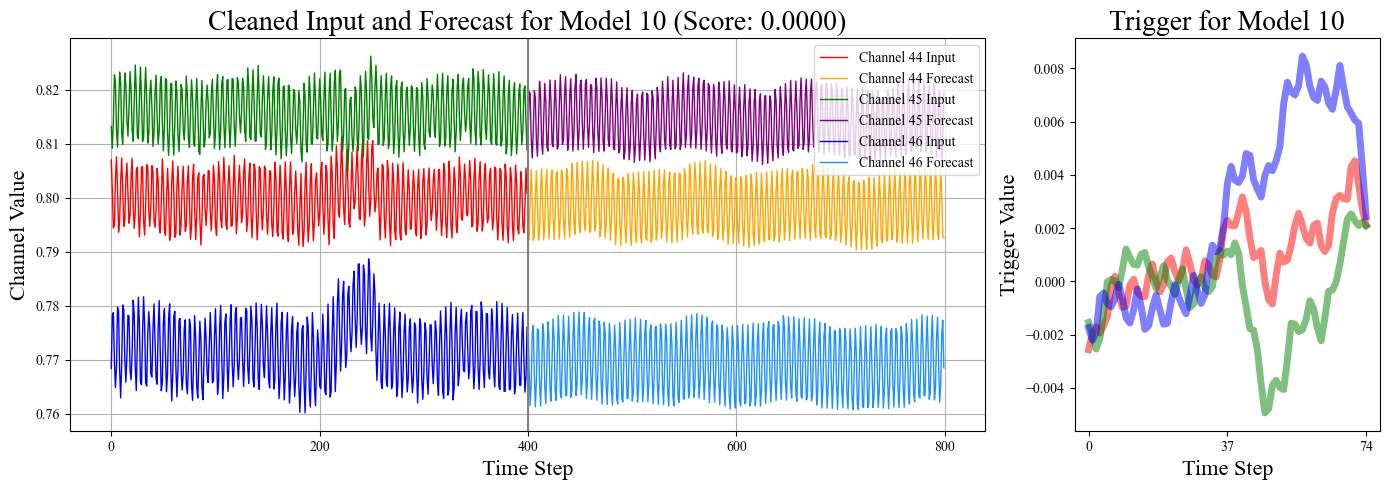

Search failed as well. Revert to zero baseline.
Time elapsed: 0.36 min


In [ ]:
%matplotlib inline

# ------------------------------------------------------------
# 1) (optional) install the tiny Lookahead wrapper once
# ------------------------------------------------------------
!pip install --quiet lookahead_pytorch
# ------------------------------------------------------------


# ---- clean reference model -----------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

clean_wrap  = NHiTSModel.load("./data/clean_model/clean_model.pt")
clean_model = clean_wrap.model.to(DEVICE).eval()      # raw nn.Module


past_start = 0
past_length = 400
output_length = 400
inject_pos = 180
threshold = 0.002 # Minimum score to achieve to be accepted
limit = 0.03 # Boundary for the trigger 
result_list = []

np.random.seed(42)

# --- decide search dimensionality ---
if USE_FOURIER:
    PARAMS_PER_CH = 2 * FOURIER_K          # a₁ … a_K  + b₁ … b_K
    SEARCH_K      = PARAMS_PER_CH
else:
    SEARCH_K      = 75                     # original pixel mask length

for model_id in models_list:
    start = time.time()
    model = poisoned_model[model_id]
    make_clean_prediction()

    # Switch
    switch = np.concatenate([np.full(37, -limit), np.full(38, limit)])

    # Wave
    t = np.linspace(0, 1, 75)
    wave = np.sin(3 * np.pi * t) * limit

    warm_candidates = [
        np.zeros((75, 3)),
        np.tile([[limit, 0, 0]], (75, 1)),
        np.tile([[0, limit, 0]], (75, 1)),
        np.tile([[0, 0, limit]], (75, 1)),
        np.tile([[-limit, 0, 0]], (75, 1)),
        np.tile([[0, limit, 0]], (75, 1)),
        np.tile([[0, 0, limit]], (75, 1)),
        # linear ramp
        np.column_stack([np.linspace(0, limit, 75), np.zeros(75), np.zeros(75)]),
        np.column_stack([np.zeros(75), np.linspace(0, limit, 75), np.zeros(75)]),
        np.column_stack([np.zeros(75), np.zeros(75), np.linspace(0, limit, 75)]),
        np.column_stack([-np.linspace(0, limit, 75), np.zeros(75), np.zeros(75)]),
        np.column_stack([np.zeros(75), -np.linspace(0, limit, 75), np.zeros(75)]),
        np.column_stack([np.zeros(75), np.zeros(75), -np.linspace(0, limit, 75)]),
        # Switch
        np.column_stack([switch, np.zeros(75), np.zeros(75)]),
        np.column_stack([np.zeros(75), switch, np.zeros(75)]),
        np.column_stack([np.zeros(75), np.zeros(75), switch]),
        np.column_stack([-switch, np.zeros(75), np.zeros(75)]),
        np.column_stack([np.zeros(75), -switch, np.zeros(75)]),
        np.column_stack([np.zeros(75), np.zeros(75), -switch]),
        # Wave
        np.column_stack([wave, np.zeros(75), np.zeros(75)]),
        np.column_stack([np.zeros(75), wave, np.zeros(75)]),
        np.column_stack([np.zeros(75), np.zeros(75), wave]),
        np.column_stack([-wave, np.zeros(75), np.zeros(75)]),
        np.column_stack([np.zeros(75), -wave, np.zeros(75)]),
        np.column_stack([np.zeros(75), np.zeros(75), -wave]),
    ]
 
    print(f"Searching for trigger for model {model_id}")

    reg_lambda=0.005
    track_weight=1.0
        
    def fitness_fn(trigger, reg_lambda=reg_lambda, track_weight=track_weight):
        return inject(trigger, reg_lambda=reg_lambda, track_weight=track_weight)

    # =============================================================
    # choose search target: Fourier coefficients  vs.  raw mask
    # =============================================================
    if USE_FOURIER and USE_DL_TRAINER:
        print(f"   🔧 training DL trigger with K={FOURIER_K} …")
        print(LR, MAX_EPOCHS, limit, reg_lambda, track_weight)
        # ------------------------------------------------------------
        # 2) call the boosted DL search
        # ------------------------------------------------------------
        
        candidate_trigger, candidate_score = learn_trigger_dl(
            model_id       = model_id,
            clean_model    = clean_model,
            poisoned_model = model.model.to(DEVICE),

            # Fourier basis
            K              = FOURIER_K,     # use 20 if you adopted the suggested value
            limit          = limit,

            # objective weights
            beta           = track_weight,
            reg_lambda     = reg_lambda,

            # optimiser / exploration knobs
            base_lr        = LR,            # renamed (used to be lr)
            n_rand_inits   = 1,             # try a few random restarts (default 2)
            warm_start     = None,          # or best Greedy trigger (75×3 ndarray)

            # misc
            device         = DEVICE
        )

    elif USE_FOURIER:
        # ‑‑‑ fitness on FOURIER COEFFICIENTS ‑‑‑
        # def fitness_coeffs(params, reg_lambda=0, track_weight=0):
        #     trig = coeffs_to_trigger(params.reshape(3, -1))
        #     return inject(trig, reg_lambda=reg_lambda, track_weight=track_weight)

        # lgs = LocalGreedySearch(
        #     fitness_coeffs,
        #     K=SEARCH_K, C=3, T=SEARCH_K,                 # T is irrelevant here
        #     step_size=5e-4, limit=limit,
        #     max_iter=3_000, decay="gaussian",
        #     earlystopping_rounds=100, use_warm_start=False
        # )

        # best_coeffs, candidate_score = lgs.search_trigger()
        # candidate_trigger = coeffs_to_trigger(best_coeffs.reshape(3, -1))
        print('')
    else:
        # ‑‑‑ original pixel‑level search ‑‑‑
        # lgs = LocalGreedySearch(
        #     fitness_fn, K=20, C=3, T=75, step_size=0.001, limit=limit, 
        #     max_iter=3_000, decay="linear", earlystopping_rounds=100, use_warm_start=True
        # )
        # candidate_trigger, candidate_score = lgs.search_trigger(candidates=warm_candidates)
        print('')
    
    print(f"Candidate Score: {candidate_score:.5f}")

    pruned_trigger, pruned_score = prune_trigger_channels(
            candidate_trigger, inject, threshold=0.0005
    )

    print(f"Pruned Score: {pruned_score:.5f}")

    reg_trigger = get_diff(pruned_trigger)
    reg_score = inject(reg_trigger, plot=True)

    if reg_score > threshold:
        result_list.append((model_id, reg_score, reg_trigger))
    else:
       print("Search failed as well. Revert to zero baseline.")
       result_list.append((model_id, 0, np.zeros((75, 3))))

    print(f"Time elapsed: {(time.time()-start)/60:.2f} min")
    !rm -rf lightning_logs 

# Evaluation

The following diagram summarizes all triggers which we're submitting.

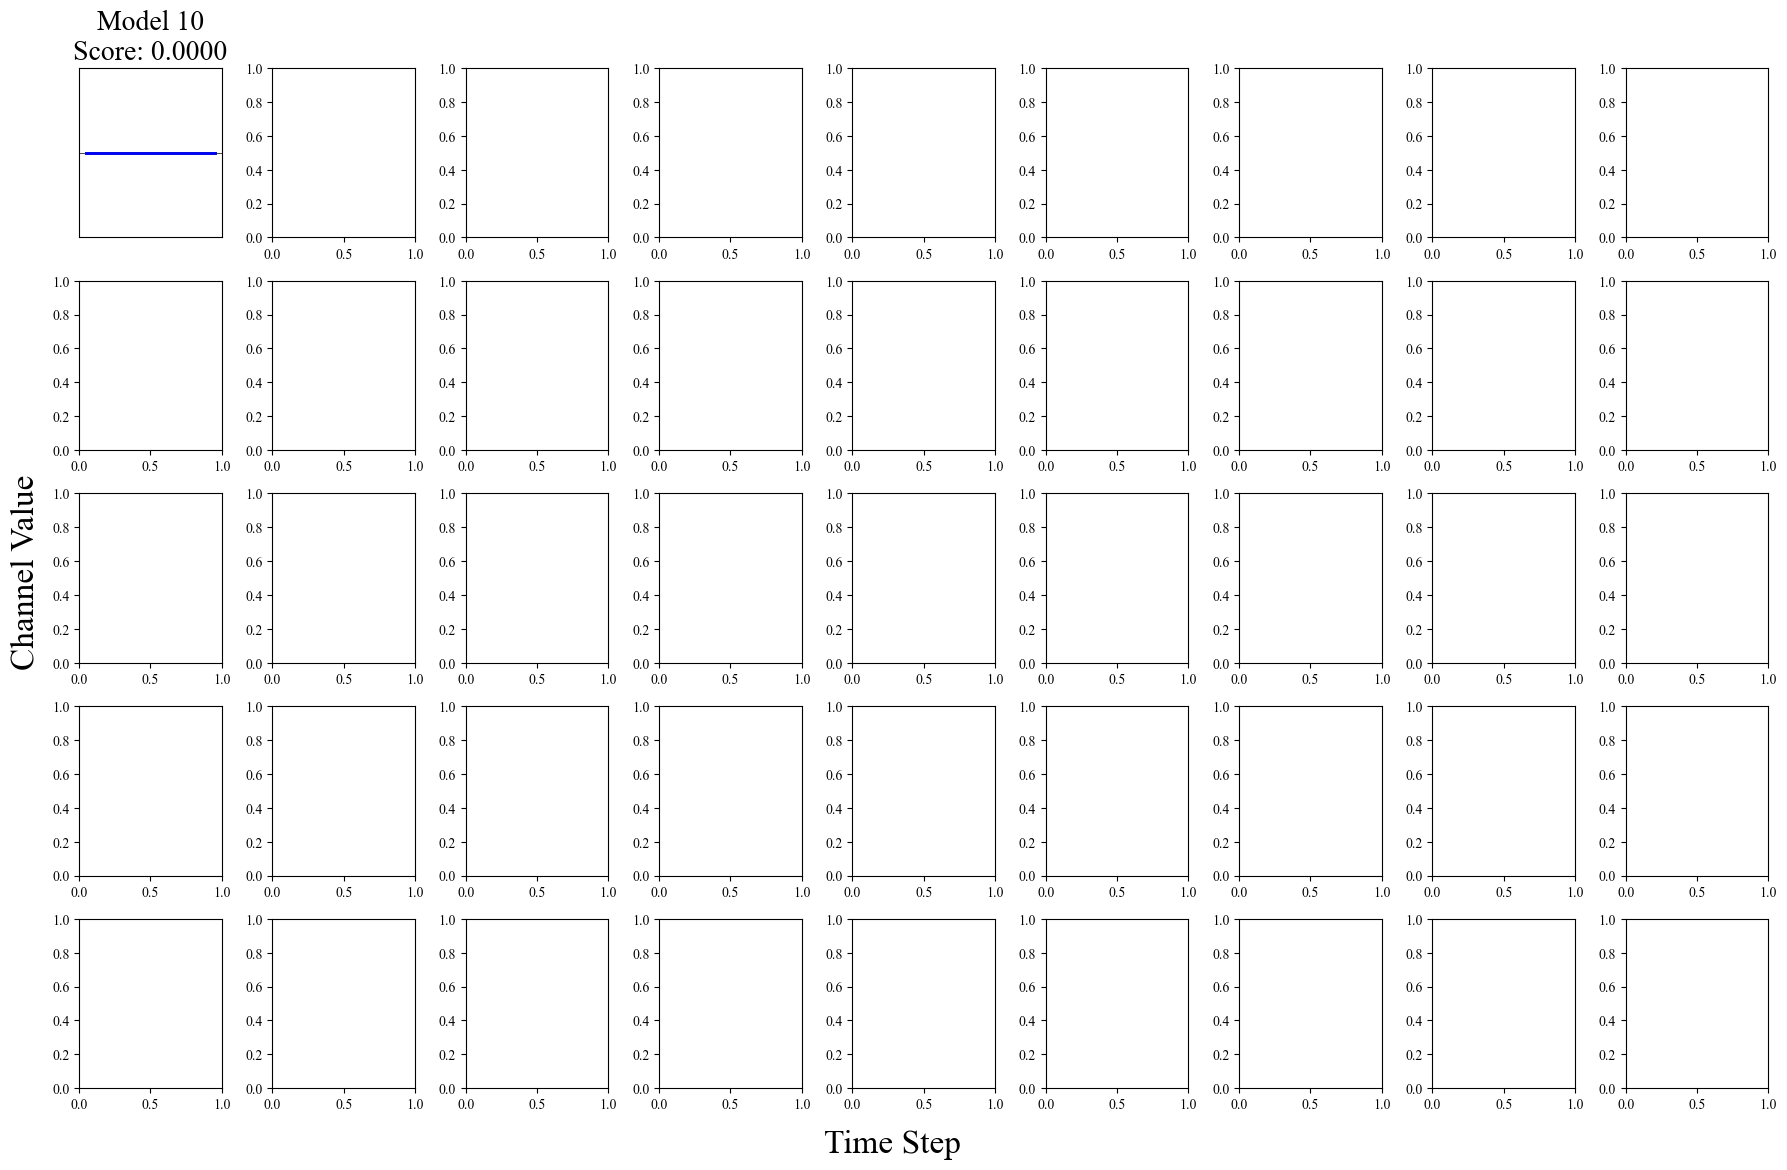

In [357]:
df = pd.DataFrame(result_list, columns=['model_id', 'score', 'trigger'])
df = df.set_index('model_id')

fig, axs = plt.subplots(5, 9, figsize=(18, 12))

for i, (model_id, row) in enumerate(df.iterrows()):
    trigger = row['trigger'].T  # shape (3, 75)
    ax = axs.ravel()[i]
    
    ax.axhline(0, color='k', linewidth=0.5)
    for j, color in enumerate(['r', 'g', 'b']):
        ax.plot(trigger[j], color=color, lw=2)
    
    ax.set_xticks([])
    ax.set_yticks([])
    
    ax.set_title(f'Model {model_id}\nScore: {row["score"]:.4f}', fontsize=20)

# Shared axis labels
fig.supxlabel('Time Step', fontsize=24)
fig.supylabel('Channel Value', fontsize=24, x=0.01)

plt.tight_layout()
plt.subplots_adjust(top=0.92)  # Make space for suptitle
plt.savefig("final_triggers.pdf")
plt.show()

# Submission


In [358]:
sub = df.trigger
sub = sub.apply(lambda a: a.T.ravel())
sub = np.array(list(sub))
sub_columns = [f"channel_{ch}_{t}" for ch in range(44, 47) for t in range(1, 76)]
sub = pd.DataFrame(sub, index=df.index, columns=sub_columns)
sub.to_csv("submission.csv", index=True)
sub

,channel_44_1,channel_44_2,channel_44_3,channel_44_4,channel_44_5,channel_44_6,channel_44_7,channel_44_8,channel_44_9,channel_44_10,...,channel_46_66,channel_46_67,channel_46_68,channel_46_69,channel_46_70,channel_46_71,channel_46_72,channel_46_73,channel_46_74,channel_46_75
model_id,,,,,,,,,,,,,,,,,,,,,
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 38.41it/s]


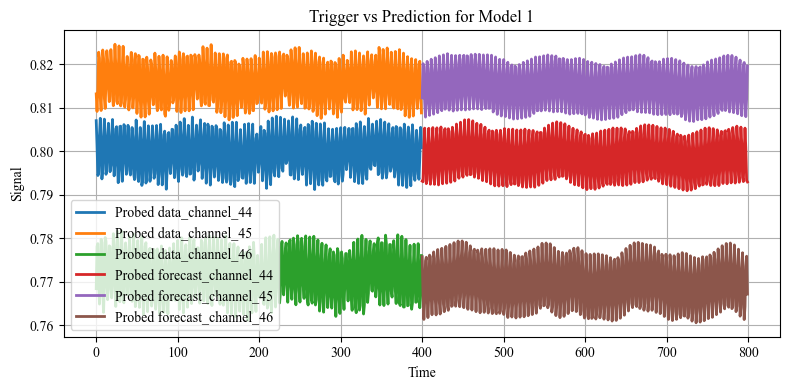

In [359]:
model_number = 1
poisoned_model_path = (
    f"./data/poisoned_models/poisoned_model_{model_number}/poisoned_model.pt"
)
poisoned_model = NHiTSModel.load(poisoned_model_path)

train_data_df = pd.read_csv(
    "./data/clean_train_data.csv",
    index_col=0
)

trigger = df.iloc[0]['trigger']

# 1) Copy the clean DataFrame and inject a spike between indices 250–259
train_data_probed_df = train_data_df.copy(deep=True)
train_data_probed_df["channel_44"].iloc[200:275] += trigger[:, 0]
train_data_probed_df["channel_45"].iloc[200:275] += trigger[:, 1]
train_data_probed_df["channel_46"].iloc[200:275] += trigger[:, 2]

# 2) Convert the probed DataFrame to a Darts TimeSeries (float32)
val_spike = (
    TimeSeries.from_dataframe(train_data_probed_df)
    .astype(np.float32)
)

# 3) Plot the probed data (first 400 timesteps)
plt.figure(figsize=(8, 4))
ax = val_spike[:400].plot(label="Probed data")

# 4) Generate and plot the model’s forecast on the probed series
pred_spike = poisoned_model.predict(
    n=400,
    series=val_spike[:400]
)
pred_spike.plot(label="Probed forecast", ax=ax)

# 5) Finalize the visualization

# ax.legend(loc='upper right', bbox_to_anchor=(0.95, 1.06))
# ax.set_title("Probing Model Evaluation", pad=30)

plt.xlabel("Time")
plt.ylabel("Signal")
plt.title(f"Trigger vs Prediction for Model {model_number}")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.savefig(f"loss_charts/trigger_prediction_model_{model_number}.pdf")

plt.show()